# Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import joblib
import warnings
warnings.filterwarnings('ignore')

# Step 2: Load Dataset

In [2]:
df = pd.read_csv("loan_prediction.csv")
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# Step 3: Data Understanding

In [3]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())


(614, 13)
<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 67.2+ KB
None
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000     

# Step 4: Data Cleaning

In [4]:
# Drop ID column if exists
if 'Loan_ID' in df.columns:
    df.drop('Loan_ID', axis=1, inplace=True)


for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)


# Step 5: Exploratory Data Analysis (EDA)

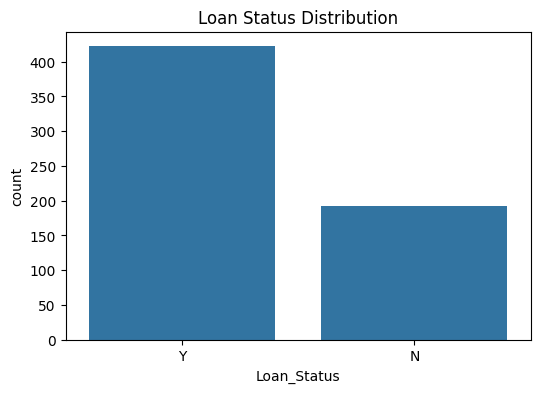

Loan Status Percentage:

Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64


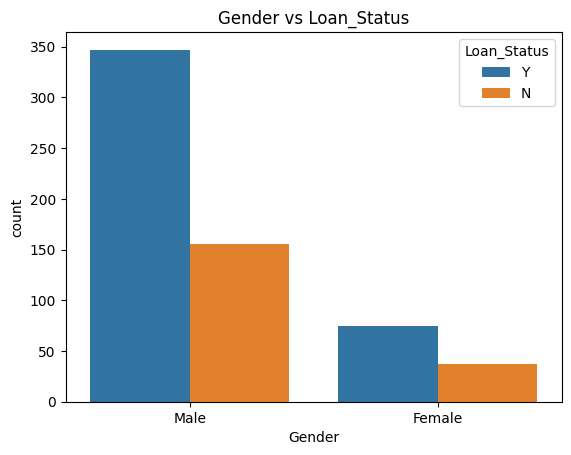

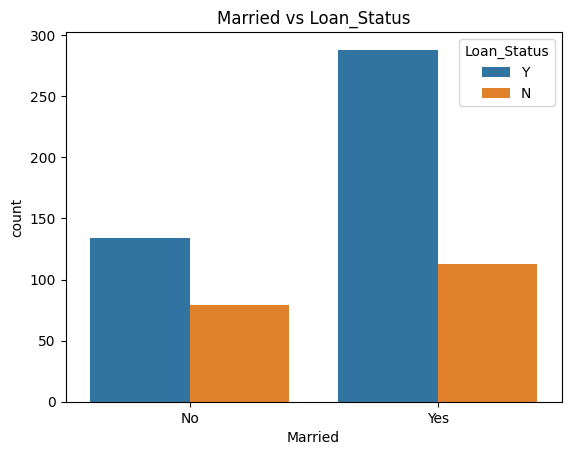

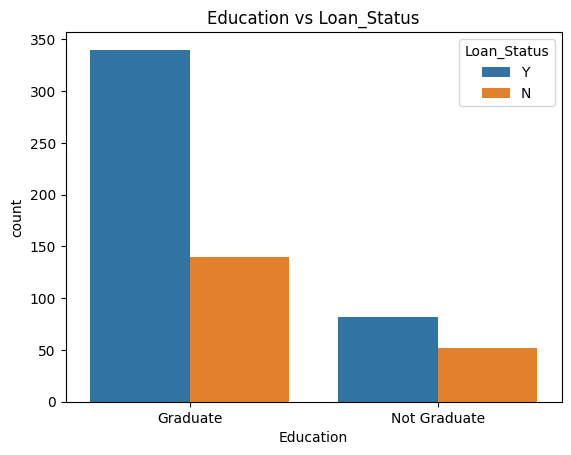

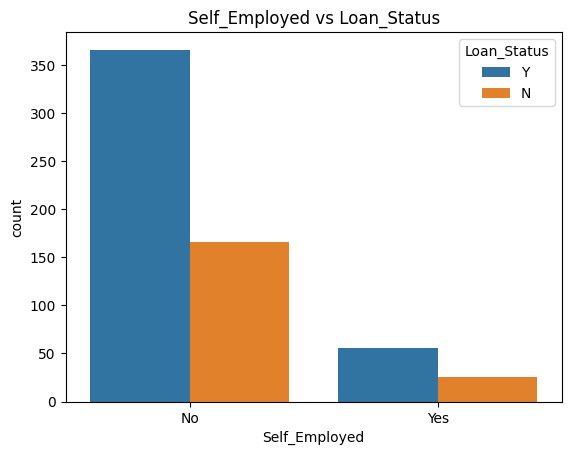

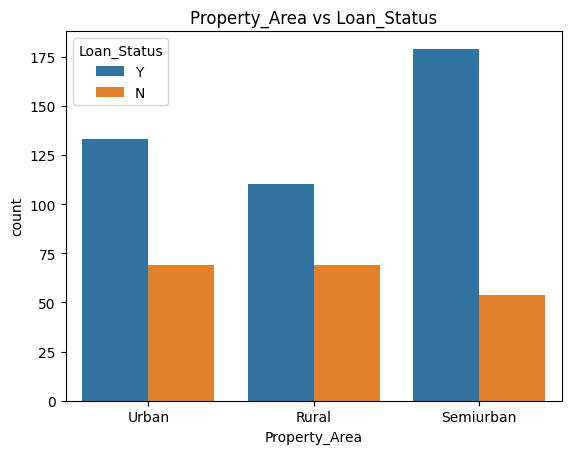

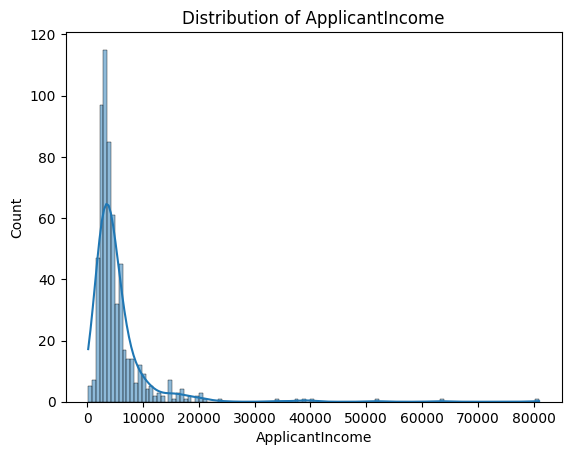

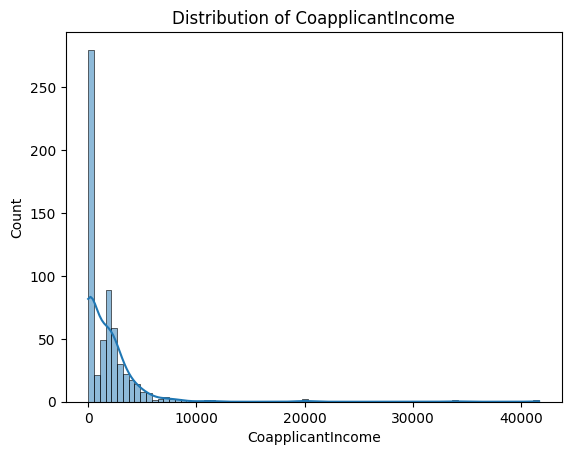

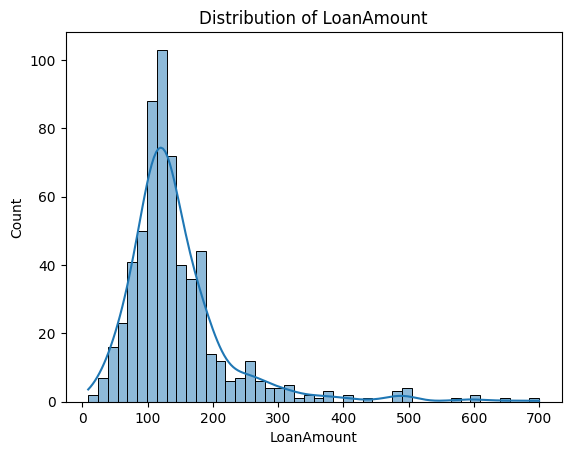

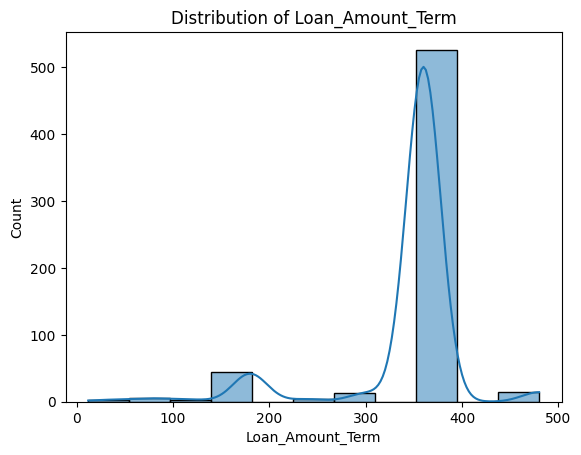

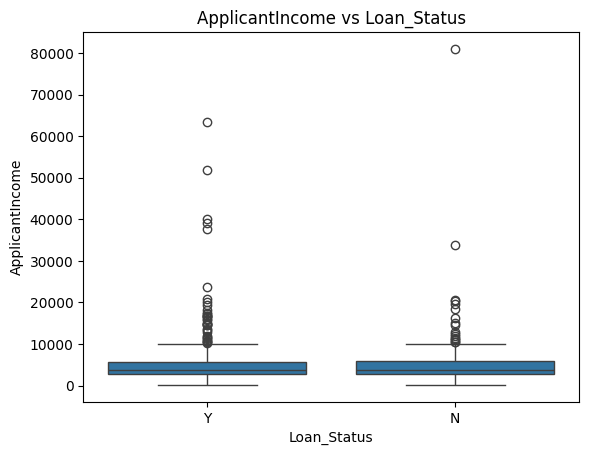

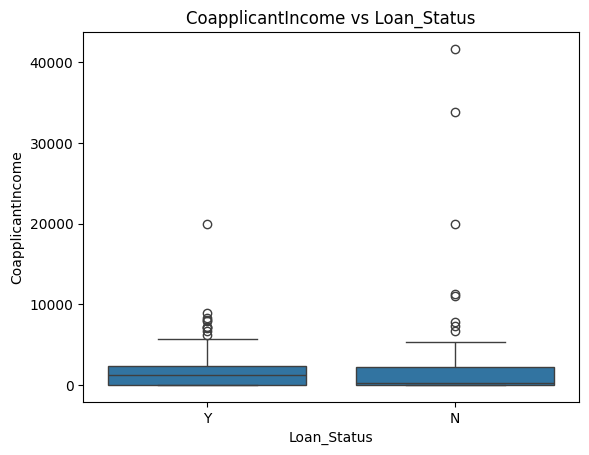

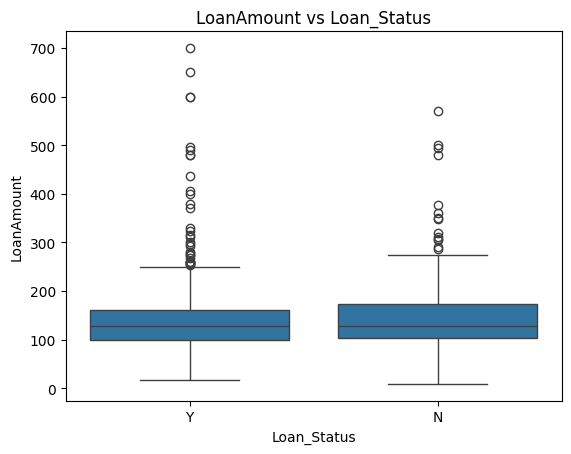

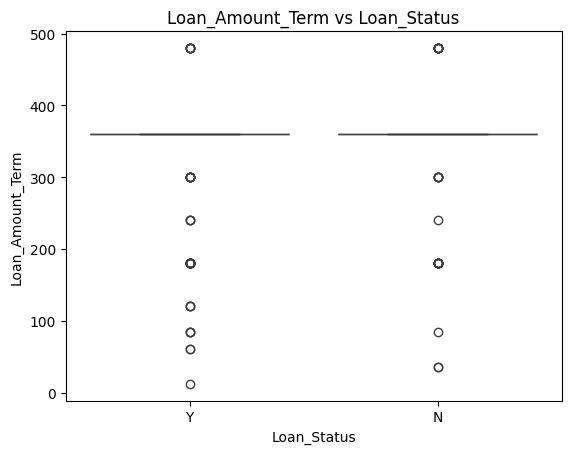

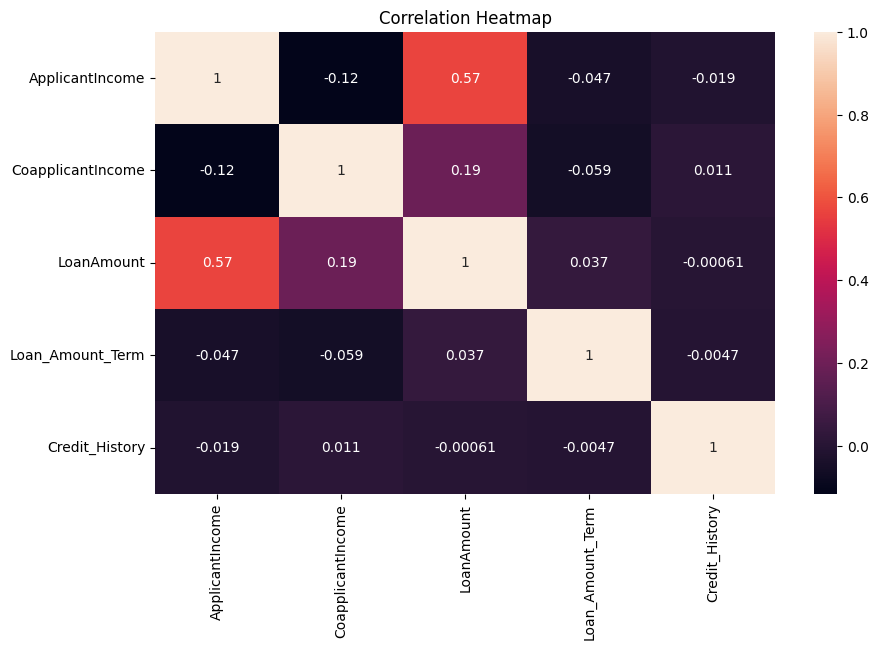

In [5]:
# 1. Target Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=df)
plt.title('Loan Status Distribution')
plt.show()

# Percentage
print("Loan Status Percentage:\n")
print(df['Loan_Status'].value_counts(normalize=True)*100)

# 2. Categorical Variables
categorical_cols = ['Gender','Married','Education','Self_Employed','Property_Area']

for col in categorical_cols:
    if col in df.columns:
        sns.countplot(x=col, hue='Loan_Status', data=df)
        plt.title(f'{col} vs Loan_Status')
        plt.show()

# 3. Numerical Distribution
numerical_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']

for col in numerical_cols:
    if col in df.columns:
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.show()

# 4. Boxplot (Outliers)
for col in numerical_cols:
    if col in df.columns:
        sns.boxplot(x='Loan_Status', y=col, data=df)
        plt.title(f'{col} vs Loan_Status')
        plt.show()

# 5. Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Step 6: Feature Engineering

In [6]:
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# Step 7: Label Encoding (Convert Categorical → Numeric)

In [7]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Step 8: Feature Scaling

In [8]:
scaler = StandardScaler()
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_scaled = scaler.fit_transform(X)


# Step 9: Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 10: Scaling

In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 11: Model Building 

In [11]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{name}")
    print("Accuracy:", acc)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.8617886178861789
[[22 16]
 [ 1 84]]
              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123


Decision Tree
Accuracy: 0.8373983739837398
[[22 16]
 [ 4 81]]
              precision    recall  f1-score   support

           0       0.85      0.58      0.69        38
           1       0.84      0.95      0.89        85

    accuracy                           0.84       123
   macro avg       0.84      0.77      0.79       123
weighted avg       0.84      0.84      0.83       123


Random Forest
Accuracy: 0.8373983739837398
[[25 13]
 [ 7 78]]
              precision    recall  f1-score   support

           0       0.78      0.66      0.71        38
           1       0.86      0.92      0.8

# Step 12: Accuracy Comparison Graph

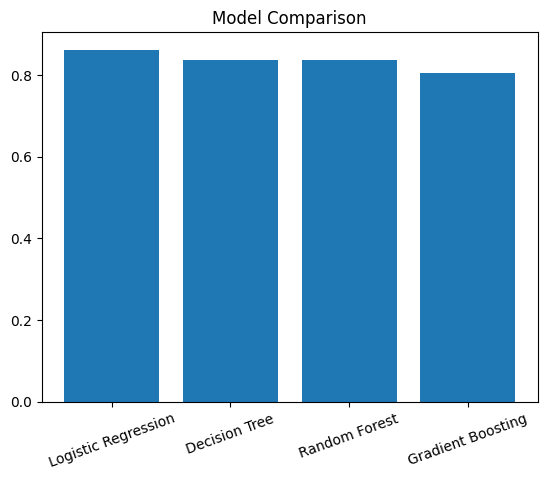

In [12]:
plt.bar(results.keys(), results.values())
plt.title("Model Comparison")
plt.xticks(rotation=20)
plt.show()

# Step 13: Best Model

In [13]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


# Confusion Matrix

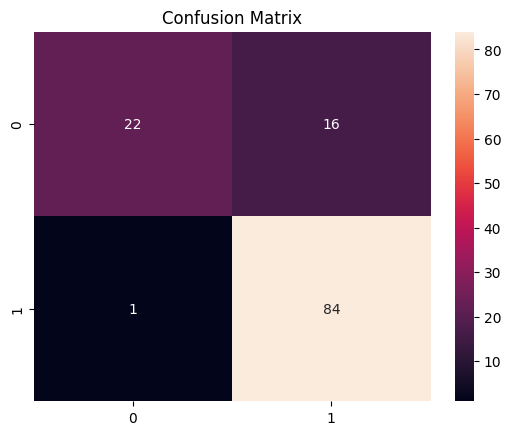

In [14]:
cm = confusion_matrix(y_test, best_model.predict(X_test))

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# Step 14: Feature Importance

In [15]:
if hasattr(best_model, "feature_importances_"):
    plt.barh(X.columns, best_model.feature_importances_)
    plt.title("Feature Importance")
    plt.show()

# Step 15: Save Model

In [16]:
joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [ ]:
!streamlit run app.py

In [19]:
df.columns
df.shape

(614, 13)

In [18]:
print(scaler.n_features_in_)

12
